# Importing Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

2025-12-17 10:40:40.598436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765968040.753391      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765968040.798314      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Data Preparation

In [4]:
from pathlib import Path

base_path = Path("/kaggle/input/eye-diseases-classification/dataset")
print("Contents:", os.listdir(base_path))


# Get all image paths
images_paths = list(base_path.glob("*/*.jpg"))

# Extract labels from parent folder names
labels = [p.parent.name for p in images_paths]


Contents: ['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


In [5]:
df = pd.DataFrame({
    "Image Path": [str(p) for p in images_paths],
    "Label": labels
})

df


,Image Path,Label
0,/kaggle/input/eye-diseases-classification/data...,glaucoma
1,/kaggle/input/eye-diseases-classification/data...,glaucoma
2,/kaggle/input/eye-diseases-classification/data...,glaucoma
3,/kaggle/input/eye-diseases-classification/data...,glaucoma
4,/kaggle/input/eye-diseases-classification/data...,glaucoma
...,...,...
2913,/kaggle/input/eye-diseases-classification/data...,cataract
2914,/kaggle/input/eye-diseases-classification/data...,cataract
2915,/kaggle/input/eye-diseases-classification/data...,cataract
2916,/kaggle/input/eye-diseases-classification/data...,cataract


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image Path  2918 non-null   object
 1   Label       2918 non-null   object
dtypes: object(2)
memory usage: 45.7+ KB


# Splitting Data To Train,Test & Validation

In [7]:
train_df , temp_df = train_test_split(df,test_size=0.3,random_state=42,stratify=df["Label"])
test_df , Valid_df = train_test_split(temp_df,test_size=0.5,stratify=temp_df["Label"])

In [8]:
print("Train Shape : ",train_df.shape)
print("Test Shape : ",test_df.shape)
print("Validation Shape ",Valid_df.shape)

Train Shape :  (2042, 2)
Test Shape :  (438, 2)
Validation Shape  (438, 2)


In [9]:
print("Train Classes : ",train_df.Label.value_counts())
print("Test Classes : ",test_df.Label.value_counts())
print("Validation Classes ",Valid_df.Label.value_counts())

Train Classes :  Label
normal      752
cataract    656
glaucoma    634
Name: count, dtype: int64
Test Classes :  Label
normal      161
cataract    141
glaucoma    136
Name: count, dtype: int64
Validation Classes  Label
normal      161
cataract    141
glaucoma    136
Name: count, dtype: int64


# Data Augmentation

In [10]:
IMG_SIZE = (224, 224)

# Training generator with augmentation
gen_tr = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    shear_range=0.2,
    rescale=1./255   # normalize pixel values
)

train_gen = gen_tr.flow_from_dataframe(
    train_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,   # ✅ fixed
    shuffle=True,
    seed=4
)

# Validation and test generators (no augmentation, only rescaling)
gen = ImageDataGenerator(rescale=1./255)

test_gen = gen.flow_from_dataframe(
    test_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=8,    # ✅ fixed
    shuffle=False
)

valid_gen = gen.flow_from_dataframe(
    Valid_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=8,    # ✅ fixed
    shuffle=False
)


Found 2042 validated image filenames belonging to 3 classes.
Found 438 validated image filenames belonging to 3 classes.
Found 438 validated image filenames belonging to 3 classes.


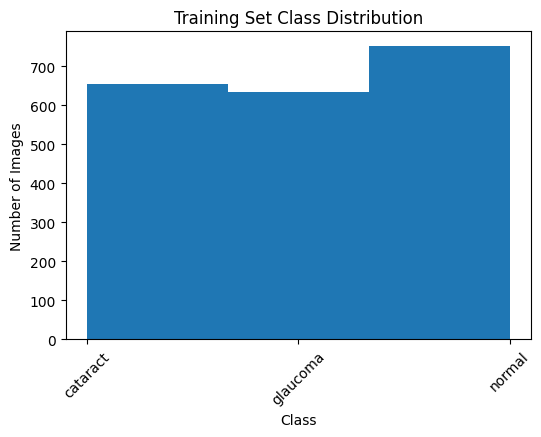

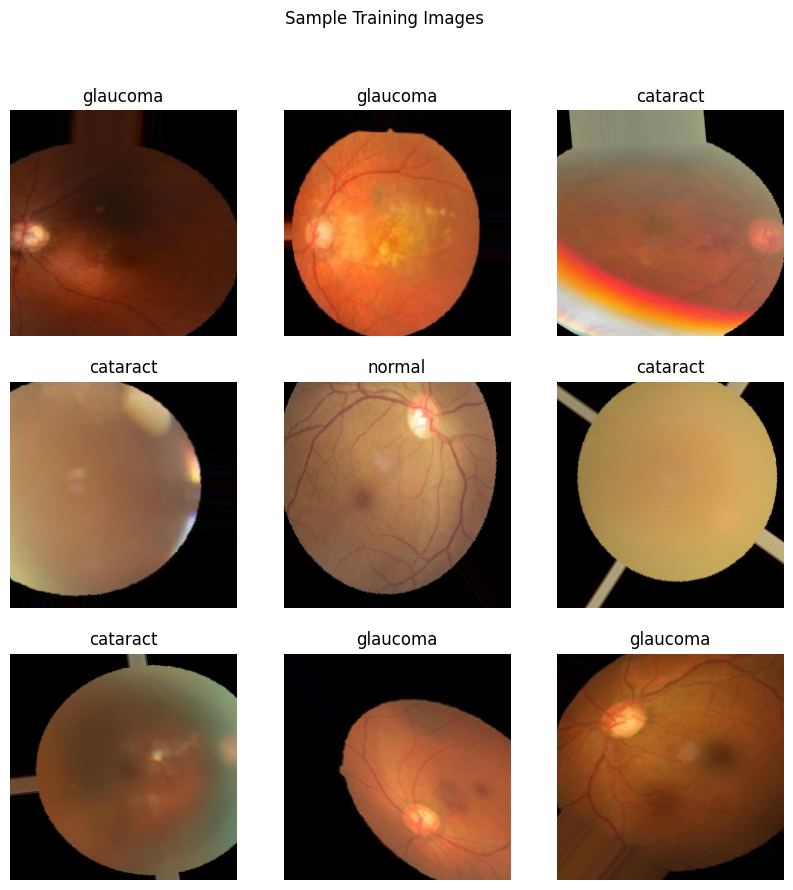

In [11]:
# Get class names from generator
class_names = list(train_gen.class_indices.keys())

# Class distribution
plt.figure(figsize=(6,4))
plt.hist(train_gen.classes, bins=len(class_names))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Sample images
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[y_batch[i].argmax()])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()


# CNN Training

In [12]:
num_classes = len(train_gen.class_indices)

model = models.Sequential([
    layers.Input(shape=(224,224,3)),   # modern way
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')   # fixed
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


I0000 00:00:1765968072.575560      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# -------------------------------
# 4. Train model
# -------------------------------
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1765968076.742233     111 service.cc:148] XLA service 0x7a96e00066f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765968076.742909     111 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765968077.023869     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/64 ━━━━━━━━━━━━━━━━━━━━ 6:04 6s/step - accuracy: 0.1875 - loss: 1.1043

I0000 00:00:1765968080.542367     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 726ms/step - accuracy: 0.3793 - loss: 1.2012 - val_accuracy: 0.4680 - val_loss: 1.0263
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.4400 - loss: 1.0580 - val_accuracy: 0.4954 - val_loss: 0.9934
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.4793 - loss: 1.0000 - val_accuracy: 0.5959 - val_loss: 1.0338
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.5931 - loss: 0.8937 - val_accuracy: 0.4954 - val_loss: 1.1646
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 398ms/step - accuracy: 0.6365 - loss: 0.8333 - val_accuracy: 0.6233 - val_loss: 0.9266


In [20]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.8467 - loss: 0.3885 - val_accuracy: 0.8288 - val_loss: 0.4531
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.8482 - loss: 0.3774 - val_accuracy: 0.8037 - val_loss: 0.5088
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.8381 - loss: 0.3986 - val_accuracy: 0.8014 - val_loss: 0.5221
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.8457 - loss: 0.3803 - val_accuracy: 0.7922 - val_loss: 0.5529
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 371ms/step - accuracy: 0.8373 - loss: 0.3952 - val_accuracy: 0.7900 - val_loss: 0.5178
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 376ms/step - accuracy: 0.8511 - loss: 0.3728 - val_accuracy: 0.8311 - val_loss: 0.4346
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.8499 - loss: 0.3829 - val_accuracy: 0.8151 - val_loss: 0.5091
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.8610 - loss: 0.3601 - val_accu

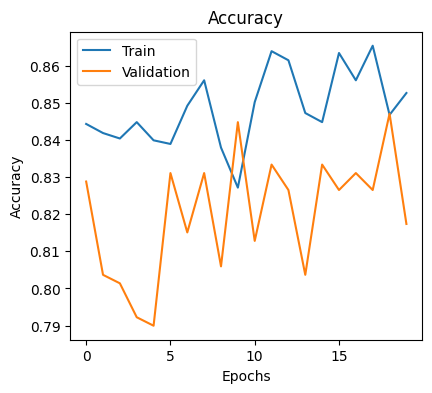

In [21]:
# -------------------------------
# 5. Plot training curves
# -------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

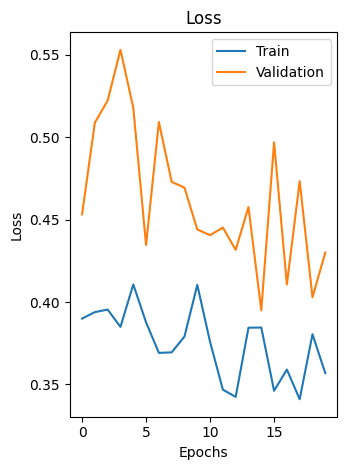

In [22]:
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# -------------------------------
# 6. Evaluate on test set
# -------------------------------
loss, acc = model.evaluate(test_gen)
print("Test accuracy:", acc)

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.8190 - loss: 0.4415
Test accuracy: 0.8287671208381653


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


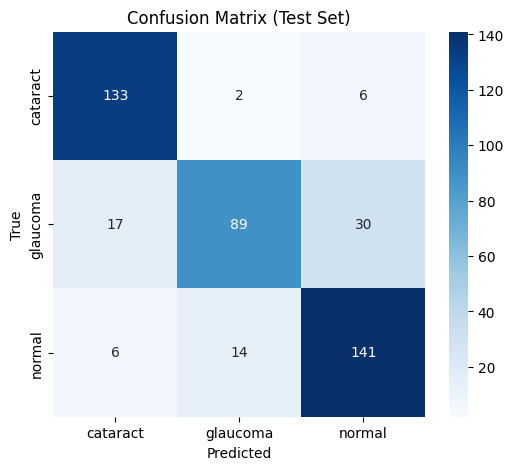

              precision    recall  f1-score   support

    cataract       0.85      0.94      0.90       141
    glaucoma       0.85      0.65      0.74       136
      normal       0.80      0.88      0.83       161

    accuracy                           0.83       438
   macro avg       0.83      0.82      0.82       438
weighted avg       0.83      0.83      0.82       438



In [24]:
# -------------------------------
# 7. Confusion Matrix
# -------------------------------
y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print(classification_report(y_true, y_pred_labels, target_names=class_names))

# Using a Pre-Trained Model

### EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


# Clearing the previous model from memory to avoid conflicts
tf.keras.backend.clear_session()

# Load EfficientNetB0 without the top classifier
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model initially
base_model.trainable = False

# Build model
num_classes = len(train_gen.class_indices)

model_eff = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_eff.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

model_eff.summary()


In [27]:
def plot_history(history, model_name="Model"):
    """
    Plots training & validation accuracy and loss curves.
    
    Args:
        history: Keras History object returned by model.fit()
        model_name: Name of the model (string) for titles
    """
    # Accuracy
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.3496 - loss: 1.0984 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.3705 - loss: 1.0958 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.3804 - loss: 1.0945 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.3637 - loss: 1.0974 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.3644 - loss: 1.0963 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.3670 - loss: 1.0969 - val_accuracy: 0.3676 - val_loss: 1.0959
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 373ms/step - accuracy: 0.3786 - loss: 1.0947 - val_accuracy: 0.3676 - val_loss: 1.0960
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.3708 - loss: 1.0958 - val_accu

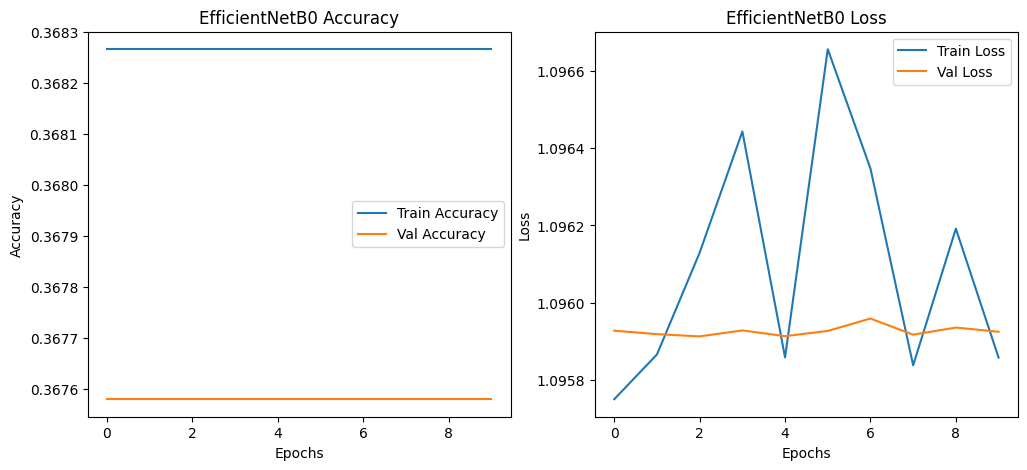

In [35]:
# EfficientNetB0
history_eff = model_eff.fit(train_gen, validation_data=valid_gen, epochs=10)
plot_history(history_eff, model_name="EfficientNetB0")

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 121s 936ms/step - accuracy: 0.5500 - loss: 0.9165 - val_accuracy: 0.3836 - val_loss: 1.0913
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 408ms/step - accuracy: 0.6036 - loss: 0.8385 - val_accuracy: 0.4612 - val_loss: 1.0202
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.6442 - loss: 0.7750 - val_accuracy: 0.3151 - val_loss: 1.1739
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 403ms/step - accuracy: 0.7029 - loss: 0.7064 - val_accuracy: 0.3904 - val_loss: 1.0971
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.7564 - loss: 0.6169 - val_accuracy: 0.2922 - val_loss: 8329.6445
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 397ms/step - accuracy: 0.7431 - loss: 0.5806 - val_accuracy: 0.1918 - val_loss: 3.0756
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.7672 - loss: 0.5714 - val_accuracy: 0.2740 - val_loss: 41.3779
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.7915 - loss: 0.5378 - val

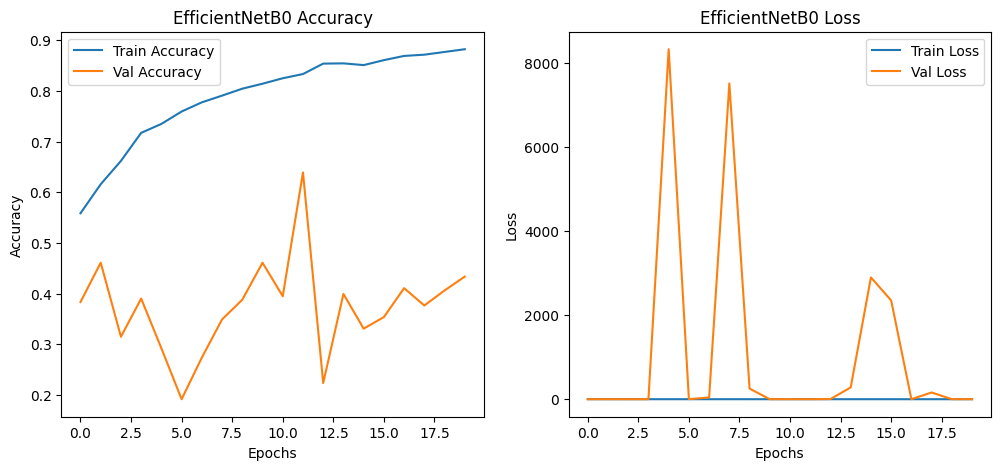

In [43]:
from tensorflow.keras.optimizers import Adam

model_eff.compile( optimizer=Adam(learning_rate=1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"] )

history_eff = model_eff.fit(train_gen, validation_data=valid_gen, epochs=20)
plot_history(history_eff, model_name="EfficientNetB0")

In [37]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])


### Resnet50

In [44]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

#Clearing the previous model from memory to avoid conflicts
tf.keras.backend.clear_session()

# Load ResNet50 without the top classifier
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model initially
base_model.trainable = False

# Build model
num_classes = len(train_gen.class_indices)

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_resnet.compile(optimizer="adam",
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

model_resnet.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [45]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 105s 811ms/step - accuracy: 0.6072 - loss: 1.1027 - val_accuracy: 0.3219 - val_loss: 2.4329
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.7702 - loss: 0.6454 - val_accuracy: 0.3219 - val_loss: 3.9746
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.8303 - loss: 0.4733 - val_accuracy: 0.3219 - val_loss: 1.7583
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.8287 - loss: 0.4896 - val_accuracy: 0.3219 - val_loss: 12.2050
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.8094 - loss: 0.4856 - val_accuracy: 0.3219 - val_loss: 13.1301
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.8382 - loss: 0.4281 - val_accuracy: 0.3219 - val_loss: 4.7610
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.8407 - loss: 0.4234 - val_accuracy: 0.3219 - val_loss: 6.1525
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.8488 - loss: 0.4096 - val_a

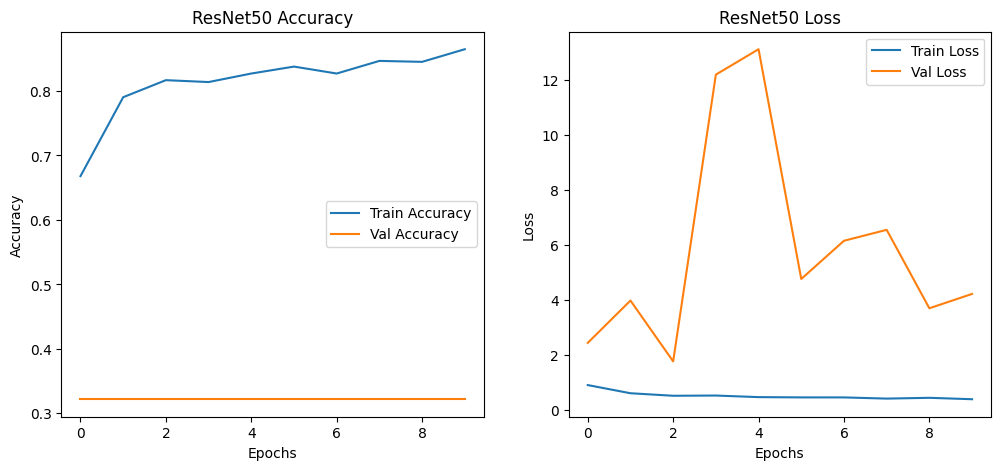

In [48]:
# ResNet50
history_resnet = model_resnet.fit(train_gen, validation_data=valid_gen, epochs=10)
plot_history(history_resnet, model_name="ResNet50")

### MobileNetV2

In [46]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers

num_classes = len(train_gen.class_indices)

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # Phase 1: freeze

model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_mobilenet.compile(optimizer="adam",
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])

model_mobilenet.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
# MobileNetV2
history_mobilenetv2 = model_mobilenet.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - accuracy: 0.7942 - loss: 0.5385 - val_accuracy: 0.7785 - val_loss: 0.5542
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 403ms/step - accuracy: 0.8137 - loss: 0.5009 - val_accuracy: 0.8082 - val_loss: 0.4851
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.8007 - loss: 0.5230 - val_accuracy: 0.7854 - val_loss: 0.5493
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.8049 - loss: 0.5062 - val_accuracy: 0.7968 - val_loss: 0.5101
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.8133 - loss: 0.4885 - val_accuracy: 0.7808 - val_loss: 0.5375
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.8375 - loss: 0.4598 - val_accuracy: 0.8014 - val_loss: 0.4690
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.8260 - loss: 0.4764 - val_accuracy: 0.7945 - val_loss: 0.5468
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.8080 - loss: 0.4774 - val_accu

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.8094 - loss: 0.4769 - val_accuracy: 0.7945 - val_loss: 0.4933
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 375ms/step - accuracy: 0.8212 - loss: 0.4671 - val_accuracy: 0.7785 - val_loss: 0.5381
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - accuracy: 0.8137 - loss: 0.4710 - val_accuracy: 0.7945 - val_loss: 0.5344
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.8112 - loss: 0.4803 - val_accuracy: 0.7991 - val_loss: 0.4950
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 377ms/step - accuracy: 0.8302 - loss: 0.4597 - val_accuracy: 0.7854 - val_loss: 0.5253
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 376ms/step - accuracy: 0.8367 - loss: 0.4438 - val_accuracy: 0.8014 - val_loss: 0.5103
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.8286 - loss: 0.4625 - val_accuracy: 0.7626 - val_loss: 0.5694
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 385ms/step - accuracy: 0.8127 - loss: 0.4578 - val_accu

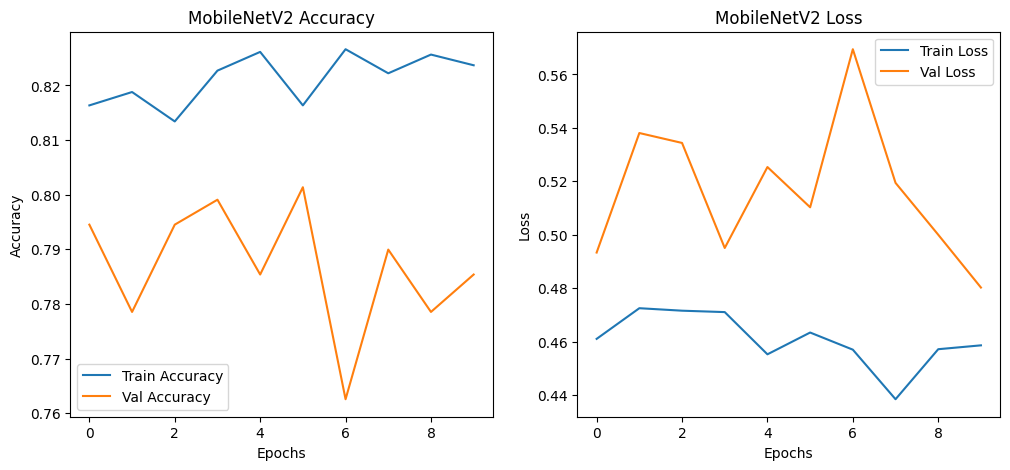

In [49]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
# MobileNetV2
history_mobilenetv2 = model_mobilenet.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10
)

plot_history(history_mobilenetv2, model_name="MobileNetV2")
